In [1]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_CBD     = "/home/miranjo/phasic_tonic/data/processed/CBD/"
DATASET_RGS     = "/home/miranjo/phasic_tonic/data/processed/RGS14/"
config_CBD      = "/home/miranjo/phasic_tonic/configs/test.yaml"
config_RGS      = "/home/miranjo/phasic_tonic/configs/rgs14.yaml"

## Setup

### Load the config file

In [2]:
with open(config_CBD, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger = logger_setup()

### Load the dataset

In [3]:
CBDfolder = DataFolder(DATASET_CBD)
RGSfolder = DataFolder(DATASET_RGS)

## Phasic and Tonic segmentation

In [9]:
OUTPUT_DIR = "/home/miranjo/phasic_tonic/data/interim/"

remFolder = CBDfolder
fs = 2500

for sample in remFolder:
    lfpREMs = sample["data"]
    metadata = sample["metadata"]
    
    for i, lfpREM in enumerate(lfpREMs):

        if(len(lfpREM) < fs):
            logger.debug("Skipping :{0}".format("_".join(metadata.values())))
            break    #Skip when the duration is less than a second
        
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)
        theta.set_metadata(metadata)
        
        # Combine all tonic episodes for each REM period
        theta_tonic = np.concatenate(theta.get_tonic(filter_type="raw"))
        logger.debug("tonic shape: {0}".format(theta_tonic.shape))

        fname = OUTPUT_DIR + theta.metaname + "_tonic" + "_" + str(i)
        np.savez(fname, theta_tonic)
        logger.info("Saving to: {0}".format(fname))

        if theta.phasic:
            # Combine all phasic episodes for each REM period
            
            theta_phasic = np.concatenate(theta.get_phasic(filter_type="raw"))
            logger.debug("phasic shape: {0}".format(theta_phasic.shape))

            fname = OUTPUT_DIR + theta.metaname + "_phasic" + "_" + str(i)
            np.savez(fname, theta_phasic)
            logger.info("Saving to: {0}".format(fname))

        else:
            logger.info("No phasic episodes detected.")

In [5]:
theta.metaname

'Rat8_SD6_OD_3_posttrial5'

## Spectral Power analysis

In [25]:
from neurodsp.spectral import compute_spectrum
#OUTPUT_DIR = "/home/miranjo/phasic_tonic/data/processed/power_spectrum"

spectrum_dict = {}

remFolder = RGSfolder
fs = 1000

cnt = 0

for sample in RGSfolder:
    lfpREMs = sample["data"]
    metadata = sample["metadata"]
    
    for i, lfpREM in enumerate(lfpREMs):
        
        if(len(lfpREM) < fs): 
            break    #Skip when the duration is less than a second
        
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)
        theta.set_metadata(metadata)

        # Combine all tonic episodes for each REM period
        theta_tonic = np.concatenate(theta.get_tonic(filter_type="raw"))
        logger.debug("tonic shape: {0}".format(theta_tonic.shape))
        
        f, spectrum_t = compute_spectrum(theta_tonic, theta.fs, method='welch', avg_type='mean')
        name = theta.metaname + "_tonic" + str(i)
        spectrum_dict[name] = spectrum_t[:100]

        if theta.phasic:
            cnt += 1
            # Combine all phasic episodes for each REM period
            theta_phasic = np.concatenate(theta.get_phasic(filter_type="raw"))
            logger.debug("phasic shape: {0}".format(theta_phasic.shape))
            
            f, spectrum_p = compute_spectrum(theta_phasic, theta.fs, method='welch', avg_type='mean')
            name = theta.metaname + "_phasic" + str(i)
            spectrum_dict[name] = spectrum_p[:100]
            
            print(theta.metaname)

/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 982, using nperseg = 982
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 855, using nperseg = 855
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 909, using nperseg = 909
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 977, using nperseg = 977
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_

In [26]:
cnt

283

In [26]:
# Save the dict object as .npy file
np.save('power_spectrum_dict', spectrum_dict)
# To load the file use
# spectras = np.load('power_spectrum_dict.npy', allow_pickle='TRUE').item()

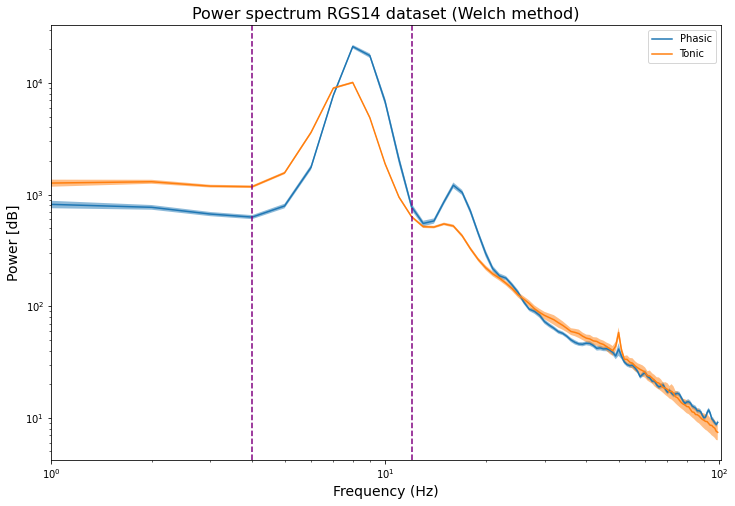

In [34]:
def get_metadata(metaname):
  """
  Parameters
  ----------
  metaname: str
    metaname consists of rat number, study day, condition, treatment value, trial number
    and phasic/tonic states followed by the REM epoch index, each separated by underscore.
    Example: Rat2_SD4_HC_2_posttrial1_tonic0

  Returns
  -------
  metadata: dict
   Dictionary object which contains each conditions.
  """
  metadata = {}

  metaname  = metaname.split('_')
  metadata["rat_id"]    = int(metaname[0][-1])
  metadata["study_day"] = int(metaname[1][-1])
  metadata["condition"] = metaname[2]
  metadata["treatment"] = int(metaname[3])
  metadata["trial_num"] = int(metaname[4][-1])
  metadata["state"]     = metaname[5][:-1]
  return metadata


phasic_spectrum = []
tonic_spectrum  = []

for metaname in spectrum_dict.keys():
  metadata = get_metadata(metaname)
  if metadata["treatment"] >= 2: # Select the RGS14 dataset
    if metadata["state"] == "tonic":
      tonic_spectrum.append(spectrum_dict[metaname])
    else:
      phasic_spectrum.append(spectrum_dict[metaname])

spectrum_phasic = np.vstack(phasic_spectrum)
spectrum_tonic = np.vstack(tonic_spectrum)

phasic_spectrum_mean = np.mean(spectrum_phasic, axis=0)
tonic_spectrum_mean = np.mean(spectrum_tonic, axis=0)

phasic_spectrum_err = np.std(spectrum_phasic, axis=0)/(len(spectrum_phasic)**0.5)
tonic_spectrum_err = np.std(spectrum_tonic, axis=0)/(len(spectrum_tonic)**0.5)

plt.figure(figsize=(12,8))
plt.plot(phasic_spectrum_mean)
plt.plot(tonic_spectrum_mean)

plt.fill_between(np.arange(100), phasic_spectrum_mean - phasic_spectrum_err,
                 phasic_spectrum_mean + phasic_spectrum_err,
                 alpha=0.5, label='Standard Error of Phasic Spectrum')

plt.fill_between(np.arange(100), tonic_spectrum_mean - tonic_spectrum_err,
                 tonic_spectrum_mean + tonic_spectrum_err,
                 alpha=0.5, label='Standard Error of Tonic Spectrum')

plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Power [dB]', fontsize=14)

plt.yscale('log')
plt.xscale('log')

plt.xlim((1, 101))

plt.axvline(x=4, color='purple', linestyle='--')
plt.axvline(x=12, color='purple', linestyle='--')

plt.title('Power spectrum RGS14 dataset (Welch method)', fontsize=16)
plt.legend(['Phasic', 'Tonic'])

In [42]:
spectrum_dict["Rat9_SD1_HC_2_posttrial5_phasic0"]

array([8.66920131e+01, 8.48143041e+01, 2.36124842e+01, 3.69556565e+01,
       1.25430355e+02, 8.16734843e+02, 7.60597824e+03, 2.18783126e+04,
       2.78943880e+04, 1.31280964e+04, 9.75970026e+02, 1.03603620e+03,
       6.83733530e+02, 7.29819315e+02, 1.40316354e+03, 5.93365254e+02,
       1.21448704e+03, 5.02779710e+02, 3.16934704e+00, 3.90343154e+02,
       6.43186403e+02, 1.86451812e+02, 1.42231853e+02, 5.97398761e+01,
       8.45014291e+01, 9.82998957e+01, 1.93149332e+01, 1.62571643e+01,
       4.85843547e+01, 5.03509405e+01, 7.15150828e+01, 9.41174994e+01,
       4.91430821e+01, 5.40475509e+01, 8.77183357e+01, 4.61487309e+01,
       9.21185173e+00, 5.48996403e+00, 4.14663681e+01, 5.75181843e+01,
       3.58918315e+01, 9.10024798e+00, 3.41554062e+01, 5.82482797e+01,
       1.25605734e+01, 1.03305815e+01, 2.62058601e+01, 8.45001308e+01,
       3.89420109e+01, 1.90025224e+01, 5.13418913e+01, 1.09698852e+01,
       7.09678999e+00, 1.32256341e+01, 4.39115037e+01, 4.71969004e+01,
      